# Alt-data regime states — k-means / GMM / HMM (r=6)

Fits the two strongest alt-data feature configs from the κ grid and exports their
**full regime-state timeseries with per-state probability vectors**, so the regime
assignment *and its uncertainty* are inspectable month-by-month — not just the binary
crisis flag the grid emits.

| Config | Universe | Sizing | Model(s) |
|---|---|---|---|
| `altdata_full/bn_meanrank` | alt-data only @1976 | Bai & Ng screen (K=9) + 3-seed `mean_rank` | **k-means**, **HMM** |
| `alt_data_only` | fixed "Current-14" @1976 | hand-curated list | **GMM**, **HMM** |

For each of the **4** (config × model) combos we export **two** CSVs:

* **full-sample** — fit once on all months ⇒ a clean descriptive state path over
  **1976–2025** with native probabilities;
* **walk-forward** — refit on data `< m` each month ⇒ the out-of-sample (no look-ahead)
  state path over **2004+**.

We then report, per combo: **(a)** cluster stability (seed ARI), **(b)** regime-conditional
Sharpe + crisis-overlay drawdown on SPY, **(c)** silhouette / BIC.

> **State count.** All three engines use **6 states**. k-means uses `RegimeModel(r=5)`
> ⇒ 6 regimes (state 0 = the Mahalanobis-outlier / crisis state + 5 cosine regimes); GMM
> and HMM use 6 mixture / hidden states. k-means probabilities are the paper's
> soft-membership (Eq 1–4, `predict_proba`), *not* true k-means posteriors — labelled as
> such.

## 1 · Setup — determinism (2 layers)

Layer 1: pin BLAS threads **before** numpy import. Layer 2: force full-SVD PCA. With
both, the pipeline is byte-reproducible. All estimators use `random_state/seed=0`.

In [1]:
import os
for _v in ('OMP_NUM_THREADS','MKL_NUM_THREADS','OPENBLAS_NUM_THREADS',
           'NUMEXPR_NUM_THREADS','VECLIB_MAXIMUM_THREADS'):
    os.environ[_v] = '1'
os.environ['PYTHONHASHSEED'] = '0'

import sys, pathlib, functools, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as _PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import f_classif
from sklearn.metrics import silhouette_score, adjusted_rand_score
warnings.filterwarnings('ignore')

ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'data'
OUT  = ROOT / 'outputs'; OUT.mkdir(exist_ok=True)

import regime_taa as rt
rt.PCA = functools.partial(_PCA, svd_solver='full')   # determinism layer 2/2
print('numpy', np.__version__, '| pandas', pd.__version__, '| regime_taa loaded')

numpy 2.4.4 | pandas 3.0.2 | regime_taa loaded


## 2 · Constants & data

* `altdata_monthly.csv` — the raw alt-data universe @1976 (pre-extracted with the grid's
  50% coverage gate); `prepare_features` transforms it into ~35 features.
* `fredmd_current.csv` — FRED-MD macro bundle, used **only** to supply the regime-label
  target that the `mean_rank` ordering is computed against (mirrors the grid).
* `etf_returns.csv` (SPY) — for regime-conditional Sharpe / drawdown.

In [2]:
WINDOW_1976 = pd.Timestamp('1976-01-01')
INIT_END    = pd.Timestamp('2017-12-01')   # selection cutoff (screen sees data <= 2017-12)
FIRST_TEST  = pd.Timestamp('2004-01-01')   # OOS / ETF anchor (walk-forward + Sharpe)
R_KM, K_GMM, K_HMM = 5, 6, 6               # KM RegimeModel(r=5) -> 6 states (0=outlier + 5 cosine); GMM/HMM -> 6 states

# Fixed "Current-14" list (alt_data_only), ordered by mean_rank (table_nb13_new_ranking.csv)
RANK14 = ['FF_RF','IR_dgs1','IR_dtb3','FF_Mkt_RF','IR_dtb6','FF_RMW','BLM_BCOMTR',
          'IR_dff','FF_HML','IR_dgs3','IR_dgs5','IR_dgs10','FF_SMB','FF_CMA']
# Expected bn_meanrank 9 (locked 2017-cutoff selection) — recomputed below and asserted.
LOCKED9 = ['FF_RF','IR_dtb3','IR_dtb6','IR_dgs1','FF_Mkt_RF','IR_dgs2','BAB_USA','FF_RMW','BLM_SPGSCI']

d  = pd.read_csv(DATA/'altdata_monthly.csv', index_col=0, parse_dates=True)
tc = pd.read_csv(DATA/'altdata_tcodes.csv', index_col=0)['tcode']
fb_alt = rt.prepare_features(d, tc, exclude='exchange', pca_var=0.95, drop_initial=2)

mdata, mtc = rt.load_fredmd(str(DATA/'fredmd_current.csv'))
fb_macro = rt.prepare_features(mdata.loc[WINDOW_1976:], mtc, exclude='exchange',
                               pca_var=0.95, drop_initial=2)

usrec = rt.load_usrec(str(DATA/'nber_usrec.csv'))
spy = pd.read_csv(DATA/'etf_returns.csv', index_col=0, parse_dates=True)['SPY']
spy.index = spy.index.to_period('M').to_timestamp()

print(f'fb_alt   : {len(fb_alt.columns)} feats -> {fb_alt.n_components} PCs  '
      f'({fb_alt.transformed.index[0].date()} -> {fb_alt.transformed.index[-1].date()})')
print(f'fb_macro : {len(fb_macro.columns)} feats -> {fb_macro.n_components} PCs')
print(f'SPY      : {spy.dropna().index[0].date()} -> {spy.dropna().index[-1].date()}')

fb_alt   : 35 feats -> 19 PCs  (1976-03-01 -> 2025-09-01)
fb_macro : 120 feats -> 58 PCs
SPY      : 2000-01-01 -> 2022-12-01


## 3 · Feature selection — recompute `bn_meanrank` (Bai & Ng + mean_rank)

The 9 features are **recomputed in-notebook** (not hardcoded):

1. **Bai & Ng (2008) screen sizes K** — for each alt feature, the t-stat of its
   point-biserial correlation with the NBER dummy over data ≤ `INIT_END`; keep those
   above `c_N = √(2 ln N)`. `K_bn` = number of survivors.
2. **`mean_rank` chooses which K** — a 3-seed RandomForest importance (gini + permutation
   + F-stat ranks) for predicting the **macro** bundle's regime labels; take the top-`K_bn`.

The result is asserted equal to the locked 2017-cutoff selection. The two PCA score
matrices are then derived by full-sample PCA on each feature subset (`subset_pca`).

In [3]:
def regime_labels(scores_df, we):
    sc = scores_df.loc[:we]
    mod = rt.RegimeModel(r=5, random_state=0, outlier_method='quantile', outlier_frac=0.15).fit(sc.values)
    return pd.Series(mod.labels_, index=sc.index)

def rank_features(fb, ylab):
    Xdf = pd.DataFrame(fb.scaler.transform(fb.transformed.values),
                       index=fb.transformed.index, columns=fb.columns)
    common = Xdf.index.intersection(ylab.index); X = Xdf.loc[common].values; yv = ylab.loc[common].values
    cols = list(fb.columns); ranks = []
    for seed in range(3):
        rf = RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=3,
                                    random_state=seed, n_jobs=1).fit(X, yv)
        gini = pd.Series(rf.feature_importances_, index=cols)
        perm = pd.Series(permutation_importance(rf, X, yv, n_repeats=3, random_state=seed,
                                                n_jobs=1).importances_mean, index=cols)
        Fst = pd.Series(np.nan_to_num(f_classif(X, yv)[0]), index=cols)
        ranks.append((gini.rank(ascending=False) + perm.rank(ascending=False)
                      + Fst.rank(ascending=False)) / 3)
    return pd.concat(ranks, axis=1).mean(axis=1).sort_values()

def screen_tstats(fb, we):
    out = {}
    for col in fb.columns:
        feat = fb.transformed[col].dropna().loc[:we]; idx = feat.index.intersection(usrec.index)
        if len(idx) < 10: out[col] = 0.0; continue
        x = feat.loc[idx].values.astype(float); y = (usrec.loc[idx] > 0).astype(float).values
        if x.std() == 0 or y.std() == 0: out[col] = 0.0; continue
        r = np.corrcoef(x, y)[0, 1]; n = len(idx)
        out[col] = np.inf if abs(r) >= 1 else float(abs(r) * np.sqrt((n - 2) / (1 - r ** 2)))
    return pd.Series(out).sort_values(ascending=False)

def subset_pca(fb, cols):
    avail = [c for c in cols if c in fb.transformed.columns]
    z = StandardScaler().fit_transform(fb.transformed[avail].values)
    cum = _PCA(svd_solver='full').fit(z).explained_variance_ratio_.cumsum()
    n = int((cum < 0.95).sum() + 1)
    sc = _PCA(n_components=n, svd_solver='full').fit_transform(z)
    return pd.DataFrame(sc, index=fb.transformed.index,
                        columns=[f'PC{i+1}' for i in range(n)]), avail, n

ts = screen_tstats(fb_alt, INIT_END)
N = len(fb_alt.columns); c_N = float(np.sqrt(2*np.log(N))); K_bn = int((ts > c_N).sum())
ylab = regime_labels(fb_macro.scores, INIT_END)
mr = rank_features(fb_alt, ylab)
FEATURES_9 = [c for c in mr.index if c in fb_alt.transformed.columns][:K_bn]
print(f'Bai & Ng screen: N={N}  c_N=sqrt(2 ln N)={c_N:.2f}  ->  K_bn={K_bn}')
print('recomputed bn_meanrank 9:', FEATURES_9)
assert set(FEATURES_9) == set(LOCKED9), 'bn_meanrank recompute drifted from the locked selection!'
print('audit OK: matches the locked 2017-cutoff selection')

scores_bn,  feats_bn,  npc_bn  = subset_pca(fb_alt, FEATURES_9)
scores_alt, feats_alt, npc_alt = subset_pca(fb_alt, RANK14)
print(f'\naltdata_full/bn_meanrank : {len(feats_bn)} feats -> {npc_bn} PCs')
print(f'alt_data_only (Current-14): {len(feats_alt)} feats -> {npc_alt} PCs')

Bai & Ng screen: N=35  c_N=sqrt(2 ln N)=2.67  ->  K_bn=9
recomputed bn_meanrank 9: ['FF_RF', 'IR_dtb3', 'IR_dtb6', 'IR_dgs1', 'FF_Mkt_RF', 'IR_dgs2', 'BAB_USA', 'FF_RMW', 'BLM_SPGSCI']
audit OK: matches the locked 2017-cutoff selection

altdata_full/bn_meanrank : 9 feats -> 7 PCs
alt_data_only (Current-14): 14 feats -> 9 PCs


## 4 · Engine machinery

`ownership_crisis` (the Mahalanobis-tail crisis-state identifier, shared by GMM/HMM) and
the pure-NumPy diagonal-Gaussian HMM (`fit_hmm` / `_hmm_filter` / `_hmm_viterbi`), pasted
verbatim from `src/altdata.py` so the notebook is standalone.

In [4]:
# ── crisis ownership (shared by GMM/HMM): state owning the most Mahalanobis-extreme months
def ownership_crisis(labels_tr, Xtr, frac=0.15):
    mu = Xtr.mean(0); VI = np.linalg.pinv(np.cov(Xtr.T)+1e-6*np.eye(Xtr.shape[1]))
    diff = Xtr - mu; dd = np.einsum('ij,jk,ik->i', diff, VI, diff)
    ext = dd >= np.quantile(dd, 1-frac); K = int(labels_tr.max())+1
    return int(np.argmax([int(ext[labels_tr==k].sum()) for k in range(K)]))

# ── pure-NumPy diagonal Gaussian HMM ──────────────────────────────────────────
def _hmm_log_emit(X, m, lv):
    T, d = X.shape; K = m.shape[0]; out = np.zeros((T, K))
    for k in range(K):
        df = X - m[k]
        out[:,k] = -0.5*(np.sum(df**2*np.exp(-lv[k]),1)+np.sum(lv[k])+d*np.log(2*np.pi))
    return out
def _hmm_fwd(lb, lA, lp):
    T,K = lb.shape; la = np.zeros((T,K)); la[0] = lp+lb[0]
    for t in range(1,T): la[t] = logsumexp(la[t-1,:,None]+lA,0)+lb[t]
    return la
def _hmm_bwd(lb, lA):
    T,K = lb.shape; b = np.zeros((T,K))
    for t in range(T-2,-1,-1): b[t] = logsumexp(lA+lb[t+1]+b[t+1],1)
    return b
def fit_hmm(X, n_states=6, n_iter=20, n_init=1, reg=1e-2, seed=0,
            init_means=None, init_vars=None, init_A=None, init_pi=None):
    T,d = X.shape; K = n_states; rng = np.random.default_rng(seed); best_ll, best = -np.inf, None
    for tr in range(n_init):
        if init_means is not None and tr==0:
            m=init_means.copy(); lv=init_vars.copy(); A=init_A.copy(); pi=init_pi.copy()
        else:
            km = KMeans(K, n_init=3, random_state=int(rng.integers(9999))).fit(X)
            m = km.cluster_centers_.copy(); lv = np.log(np.full((K,d), X.var(0).clip(1e-6))+reg)
            A = np.full((K,K), 0.05/(K-1)); np.fill_diagonal(A, 0.95); pi = np.ones(K)/K
        lp = -np.inf
        for _ in range(n_iter):
            lb=_hmm_log_emit(X,m,lv); lA=np.log(A+1e-300); lpi=np.log(pi+1e-300)
            la=_hmm_fwd(lb,lA,lpi); bw=_hmm_bwd(lb,lA); ll=float(logsumexp(la[-1]))
            lg=la+bw; lg-=logsumexp(lg,1,keepdims=True); gg=np.exp(lg); xi=np.zeros((K,K))
            for t in range(T-1):
                lx=la[t,:,None]+lA+lb[t+1]+bw[t+1]; xi+=np.exp(lx-logsumexp(lx))
            gs=gg.sum(0).clip(1e-10); pi=gg[0]/gg[0].sum(); A=xi/xi.sum(1,keepdims=True).clip(1e-10)
            m=(gg[:,:,None]*X[:,None,:]).sum(0)/gs[:,None]
            for k in range(K):
                df=X-m[k]; v=(gg[:,k,None]*df**2).sum(0)/gs[k]+reg; lv[k]=np.log(v)
            if abs(ll-lp)<1e-3: break
            lp=ll
        if ll>best_ll: best_ll=ll; best=(m.copy(),lv.copy(),A.copy(),pi.copy())
    return (*best, best_ll)
def _hmm_filter(X,m,lv,A,pi):
    lb=_hmm_log_emit(X,m,lv); la=_hmm_fwd(lb,np.log(A+1e-300),np.log(pi+1e-300))
    la-=logsumexp(la,1,keepdims=True); return np.exp(la)
def _hmm_viterbi(X,m,lv,A,pi):
    T,K=len(X),m.shape[0]; lb=_hmm_log_emit(X,m,lv); lA=np.log(A+1e-300)
    ld=np.zeros((T,K)); ps=np.zeros((T,K),int); ld[0]=np.log(pi+1e-300)+lb[0]
    for t in range(1,T): sc=ld[t-1,:,None]+lA; ps[t]=sc.argmax(0); ld[t]=sc.max(0)+lb[t]
    s=np.zeros(T,int); s[-1]=ld[-1].argmax()
    for t in range(T-2,-1,-1): s[t]=ps[t+1,s[t+1]]
    return s
print('engine machinery ready')

engine machinery ready


## 5 · Fitters, exporters & diagnostics

**Full-sample** fit (descriptive path, 1976–2025): k-means `RegimeModel(r=5)` →
`labels_` + `predict_proba` (6 cols); GMM(6) → `predict` + `predict_proba` (6 cols) +
native BIC; HMM(6, n_init=3, n_iter=50) → Viterbi path + filtered posteriors (6 cols) +
native BIC. Crisis = state 0 (KM) or `ownership_crisis` (GMM/HMM).

**Walk-forward** (OOS, 2004+): refit on `scores < m` each month (full-sample PCA,
expanding-window clustering — matches the grid detectors). We export the per-month
`state` (window-local id), the consistent `crisis` flag, `p_crisis` (posterior mass on the
identified crisis state — the cross-window-comparable probability), and the window-local
`p_state*` vector. **Note:** non-crisis state ids are *not* cross-window consistent (no
Hungarian re-matching); `crisis` / `p_crisis` are the comparable series.

**Diagnostics** (computed on the full-sample fit): seed-ARI cluster stability,
regime-conditional Sharpe + crisis-overlay drawdown on SPY (2004+), silhouette, BIC.

In [5]:
SUMMARY, FULL = {}, {}

# ---- full-sample fitters: return (states, proba[T,K], crisis[T], fitobj) ----
def km_fit_full(scores):
    X = scores.values
    mdl = rt.RegimeModel(r=R_KM, n_init=10, outlier_method='quantile',
                         outlier_frac=0.15, random_state=0).fit(X)
    states = mdl.labels_.astype(int)            # 0..R_KM  (6 states; 0 = outlier/crisis)
    proba  = mdl.predict_proba(X)               # (T, R_KM+1) paper soft-membership
    crisis = (states == 0).astype(int)
    return states, proba, crisis, None

def gmm_fit_full(scores):
    X = scores.values
    gm = GaussianMixture(K_GMM, covariance_type='diag', n_init=10, random_state=0,
                         reg_covar=1e-6, max_iter=100).fit(X)
    states = gm.predict(X).astype(int)          # 0..K_GMM-1
    proba  = gm.predict_proba(X)
    cs = ownership_crisis(states, X)
    crisis = (states == cs).astype(int)
    return states, proba, crisis, gm

def hmm_fit_full(scores, n_iter=50, n_init=3, seed=0):
    X = scores.values
    m, lv, A, pi, ll = fit_hmm(X, n_states=K_HMM, n_iter=n_iter, n_init=n_init, seed=seed)
    states = _hmm_viterbi(X, m, lv, A, pi).astype(int)
    proba  = _hmm_filter(X, m, lv, A, pi)
    cs = ownership_crisis(states, X)
    crisis = (states == cs).astype(int)
    return states, proba, crisis, (m, lv, A, pi, ll)

# ---- walk-forward (OOS, 2004+) ----
def _wf_frame(rows, ncol):
    idx = list(rows.keys()); df = pd.DataFrame(index=pd.DatetimeIndex(idx))
    df['state']    = [rows[m][0] for m in idx]
    df['crisis']   = [rows[m][1] for m in idx]
    df['p_crisis'] = [rows[m][2] for m in idx]
    P = np.vstack([rows[m][3] for m in idx])
    for k in range(ncol): df[f'p_state{k}'] = P[:, k]
    return df

def km_walkforward(scores):
    idx = scores.index[scores.index >= FIRST_TEST]; rows = {}
    for m in idx:
        Xtr = scores.loc[scores.index < m].values; xm = scores.loc[[m]].values
        mdl = rt.RegimeModel(r=R_KM, n_init=10, outlier_method='quantile',
                             outlier_frac=0.15, random_state=0).fit(Xtr)
        pr = mdl.predict_proba(xm)[0]
        rows[m] = (int(mdl.hard_labels(xm)[0]), int(mdl._is_outlier(xm)[0]), float(pr[0]), pr)
    return _wf_frame(rows, R_KM+1)

def gmm_walkforward(scores):
    idx = scores.index[scores.index >= FIRST_TEST]; rows = {}
    for m in idx:
        Xtr = scores.loc[scores.index < m].values; xm = scores.loc[[m]].values
        gm = GaussianMixture(K_GMM, covariance_type='diag', n_init=10, random_state=0,
                             reg_covar=1e-6, max_iter=100).fit(Xtr)
        cs = ownership_crisis(gm.predict(Xtr), Xtr)
        pr = gm.predict_proba(xm)[0]; st = int(gm.predict(xm)[0])
        rows[m] = (st, int(st == cs), float(pr[cs]), pr)
    return _wf_frame(rows, K_GMM)

def hmm_walkforward(scores):
    idx = scores.index[scores.index >= FIRST_TEST]; rows = {}; warm = None
    for m in idx:
        Xtr = scores.loc[scores.index < m].values; xm = scores.loc[[m]].values
        kw = dict(init_means=warm[0], init_vars=warm[1], init_A=warm[2], init_pi=warm[3]) if warm else {}
        mm, lv, A, pi, ll = fit_hmm(Xtr, n_states=K_HMM, n_iter=20, n_init=1, seed=0, **kw)
        if not np.isfinite(ll): mm, lv, A, pi, ll = fit_hmm(Xtr, n_states=K_HMM, n_iter=20, n_init=1, seed=0)
        warm = (mm, lv, A, pi)
        cs = ownership_crisis(_hmm_viterbi(Xtr, mm, lv, A, pi), Xtr)
        post = _hmm_filter(np.vstack([Xtr, xm]), mm, lv, A, pi)[-1]
        st = int(np.argmax(post))
        rows[m] = (st, int(st == cs), float(post[cs]), post)
    return _wf_frame(rows, K_HMM)

# ---- exporters ----
def export_full(name, scores, states, proba, crisis):
    df = pd.DataFrame({'state': states, 'crisis': crisis}, index=scores.index)
    for k in range(proba.shape[1]): df[f'p_state{k}'] = proba[:, k]
    df.to_csv(OUT / f'states_{name}_fullsample.csv')
    return df

def export_wf(name, df):
    df.to_csv(OUT / f'states_{name}_walkforward.csv'); return df

# ---- diagnostics ----
def stability_ari(scores, kind, n_seed=10):
    X = scores.values
    if kind == 'km':
        ref = rt.RegimeModel(r=R_KM, n_init=10, outlier_method='quantile',
                             outlier_frac=0.15, random_state=0).fit(X).labels_
        fits = [rt.RegimeModel(r=R_KM, n_init=10, outlier_method='quantile',
                outlier_frac=0.15, random_state=s).fit(X).labels_ for s in range(1, n_seed+1)]
    elif kind == 'gmm':
        ref = GaussianMixture(K_GMM, covariance_type='diag', n_init=10, random_state=0,
                              reg_covar=1e-6, max_iter=100).fit(X).predict(X)
        fits = [GaussianMixture(K_GMM, covariance_type='diag', n_init=10, random_state=s,
                reg_covar=1e-6, max_iter=100).fit(X).predict(X) for s in range(1, n_seed+1)]
    else:  # hmm (fewer seeds — EM is the expensive fit)
        n_seed = min(n_seed, 5)
        m, lv, A, pi, _ = fit_hmm(X, n_states=K_HMM, n_iter=50, n_init=3, seed=0)
        ref = _hmm_viterbi(X, m, lv, A, pi); fits = []
        for s in range(1, n_seed+1):
            mm, lvv, AA, pp, _ = fit_hmm(X, n_states=K_HMM, n_iter=30, n_init=1, seed=s)
            fits.append(_hmm_viterbi(X, mm, lvv, AA, pp))
    aris = [adjusted_rand_score(ref, f) for f in fits]
    return float(np.mean(aris)), float(np.std(aris))

def regime_perf(scores, states, crisis):
    lab = pd.Series(states, index=scores.index); cf = pd.Series(crisis, index=scores.index)
    win = spy.index.intersection(scores.index); win = win[win >= FIRST_TEST]
    r = spy.loc[win]; lw = lab.loc[win]; cw = cf.loc[win]
    ann = lambda x: float(np.sqrt(12)*x.dropna().mean()/x.dropna().std()) if x.dropna().std() > 0 else float('nan')
    mdd = lambda x: float(((1+x.fillna(0)).cumprod() / (1+x.fillna(0)).cumprod().cummax() - 1).min())
    cond = r.groupby(lw).apply(ann)
    overlay = r.where(cw == 0, 0.0)
    return dict(cond_sharpe=cond, buyhold_sharpe=ann(r), overlay_sharpe=ann(overlay),
                buyhold_maxdd=mdd(r), overlay_maxdd=mdd(overlay), dd_improvement=mdd(overlay)-mdd(r),
                sharpe_spread=float(cond.max()-cond.min()) if len(cond) else float('nan'))

def bic_silhouette(scores, states, kind, fitobj):
    X = scores.values
    sil = float(silhouette_score(X, states)) if len(set(states)) > 1 else float('nan')
    if kind == 'gmm':
        bic = float(fitobj.bic(X))
    elif kind == 'hmm':
        m, lv, A, pi, ll = fitobj; T, dd = X.shape; K = K_HMM
        p = K*dd + K*dd + K*(K-1) + (K-1)           # means + diag vars + transitions + init
        bic = float(-2*ll + p*np.log(T))
    else:  # km — proxy BIC via a same-#states full-cov GMM
        bic = float(GaussianMixture(R_KM+1, covariance_type='full', random_state=0).fit(X).bic(X))
    return sil, bic

# ---- one-call driver per combo ----
def run_combo(name, config_label, model, scores, feats, npc):
    if model == 'kmeans':
        st, pr, cr, fit = km_fit_full(scores);  kind, wf = 'km',  km_walkforward(scores)
    elif model == 'gmm':
        st, pr, cr, fit = gmm_fit_full(scores); kind, wf = 'gmm', gmm_walkforward(scores)
    else:
        st, pr, cr, fit = hmm_fit_full(scores); kind, wf = 'hmm', hmm_walkforward(scores)
    export_full(name, scores, st, pr, cr); export_wf(name, wf)
    ari_m, ari_s = stability_ari(scores, kind)
    perf = regime_perf(scores, st, cr)
    sil, bic = bic_silhouette(scores, st, kind, fit)
    SUMMARY[name] = dict(config=config_label, model=model, n_feats=len(feats), n_pcs=npc,
        n_states=int(pr.shape[1]), silhouette=round(sil,3), bic=round(bic,1),
        ari_mean=round(ari_m,3), ari_std=round(ari_s,3),
        buyhold_sharpe=round(perf['buyhold_sharpe'],3), overlay_sharpe=round(perf['overlay_sharpe'],3),
        buyhold_maxdd=round(perf['buyhold_maxdd'],3), overlay_maxdd=round(perf['overlay_maxdd'],3),
        dd_improvement=round(perf['dd_improvement'],3), sharpe_spread=round(perf['sharpe_spread'],3))
    FULL[name] = dict(scores=scores, states=st, crisis=cr, proba=pr, cond=perf['cond_sharpe'])
    print(f'[{name}]  states={pr.shape[1]}  sil={sil:+.3f}  bic={bic:.0f}  '
          f'ARI={ari_m:.3f}+/-{ari_s:.3f}  dd_impr={perf["dd_improvement"]:+.3f}  '
          f'crisis_months(full)={int(np.sum(cr))}  wf_rows={len(wf)}')
    return st, pr, cr

print('fitters + diagnostics ready')

fitters + diagnostics ready


## 6 · Combo 1 — `altdata_full/bn_meanrank` × k-means

6 states (0 = crisis/outlier). Exports `states_altdata_bnmeanrank_kmeans_fullsample.csv`
and `…_walkforward.csv`. Below: the regime-conditional annualized SPY Sharpe by state.

In [6]:
run_combo('altdata_bnmeanrank_kmeans', 'altdata_full/bn_meanrank', 'kmeans',
          scores_bn, feats_bn, npc_bn)
FULL['altdata_bnmeanrank_kmeans']['cond'].round(3).rename('cond_sharpe').to_frame()

[altdata_bnmeanrank_kmeans]  states=6  sil=+0.076  bic=10897  ARI=0.909+/-0.143  dd_impr=+0.340  crisis_months(full)=90  wf_rows=261


,cond_sharpe
0,-0.203
1,-0.898
2,1.643
3,4.322
4,-1.279
5,1.343


## 7 · Combo 2 — `altdata_full/bn_meanrank` × HMM

6 states; crisis = `ownership_crisis`. Exports `states_altdata_bnmeanrank_hmm_*`.

In [7]:
run_combo('altdata_bnmeanrank_hmm', 'altdata_full/bn_meanrank', 'hmm',
          scores_bn, feats_bn, npc_bn)
FULL['altdata_bnmeanrank_hmm']['cond'].round(3).rename('cond_sharpe').to_frame()

[altdata_bnmeanrank_hmm]  states=6  sil=+0.009  bic=9926  ARI=0.858+/-0.073  dd_impr=+0.000  crisis_months(full)=41  wf_rows=261


,cond_sharpe
0,-0.549
3,1.140
5,1.332


## 8 · Combo 3 — `alt_data_only` (Current-14) × GMM

6 states with **native** `predict_proba` posteriors + native BIC. This config had the
highest GMM κ in the grid. Exports `states_altdataonly_gmm_*`.

In [8]:
run_combo('altdataonly_gmm', 'alt_data_only', 'gmm',
          scores_alt, feats_alt, npc_alt)
FULL['altdataonly_gmm']['cond'].round(3).rename('cond_sharpe').to_frame()

[altdataonly_gmm]  states=6  sil=+0.007  bic=15408  ARI=0.507+/-0.098  dd_impr=+0.151  crisis_months(full)=68  wf_rows=261


,cond_sharpe
0,2.321
1,-1.115
2,2.100
3,-1.879
5,3.774


## 9 · Combo 4 — `alt_data_only` (Current-14) × HMM

6 states. Exports `states_altdataonly_hmm_*`.

In [9]:
run_combo('altdataonly_hmm', 'alt_data_only', 'hmm',
          scores_alt, feats_alt, npc_alt)
FULL['altdataonly_hmm']['cond'].round(3).rename('cond_sharpe').to_frame()

[altdataonly_hmm]  states=6  sil=-0.014  bic=14696  ARI=0.798+/-0.143  dd_impr=+0.372  crisis_months(full)=87  wf_rows=261


,cond_sharpe
3,1.789
4,1.334
5,-0.789


## 10 · Diagnostics summary

One row per combo: silhouette, BIC, seed-ARI cluster stability, and the regime-conditional
Sharpe spread + crisis-overlay drawdown improvement on SPY (2004+). Saved to
`table_diagnostics_summary.csv`.

In [10]:
order = ['config','model','n_feats','n_pcs','n_states','silhouette','bic',
         'ari_mean','ari_std','buyhold_sharpe','overlay_sharpe','buyhold_maxdd',
         'overlay_maxdd','dd_improvement','sharpe_spread']
summ = pd.DataFrame(SUMMARY).T[order]
summ.to_csv(OUT/'table_diagnostics_summary.csv')
print('wrote', (OUT/'table_diagnostics_summary.csv').name)
print('exported state CSVs:', sorted(p.name for p in OUT.glob('states_*.csv')))
summ

wrote table_diagnostics_summary.csv
exported state CSVs: ['states_altdata_bnmeanrank_hmm_fullsample.csv', 'states_altdata_bnmeanrank_hmm_walkforward.csv', 'states_altdata_bnmeanrank_kmeans_fullsample.csv', 'states_altdata_bnmeanrank_kmeans_walkforward.csv', 'states_altdataonly_gmm_fullsample.csv', 'states_altdataonly_gmm_walkforward.csv', 'states_altdataonly_hmm_fullsample.csv', 'states_altdataonly_hmm_walkforward.csv']


,config,model,n_feats,n_pcs,n_states,silhouette,bic,ari_mean,ari_std,buyhold_sharpe,overlay_sharpe,buyhold_maxdd,overlay_maxdd,dd_improvement,sharpe_spread
altdata_bnmeanrank_kmeans,altdata_full/bn_meanrank,kmeans,9,7,6,0.076,10896.9,0.909,0.143,0.644,0.865,-0.508,-0.168,0.34,5.601
altdata_bnmeanrank_hmm,altdata_full/bn_meanrank,hmm,9,7,6,0.009,9926.1,0.858,0.073,0.644,0.644,-0.508,-0.508,0.0,1.881
altdataonly_gmm,alt_data_only,gmm,14,9,6,0.007,15407.8,0.507,0.098,0.644,0.816,-0.508,-0.357,0.151,5.653
altdataonly_hmm,alt_data_only,hmm,14,9,6,-0.014,14695.8,0.798,0.143,0.644,1.224,-0.508,-0.135,0.372,2.578


## 11 · Regime-state paths (full-sample) vs NBER

Per combo: the assigned state over time (step line), grey = NBER recession, red = the
model's crisis flag. Saved to `fig_state_paths.png`.

wrote fig_state_paths.png


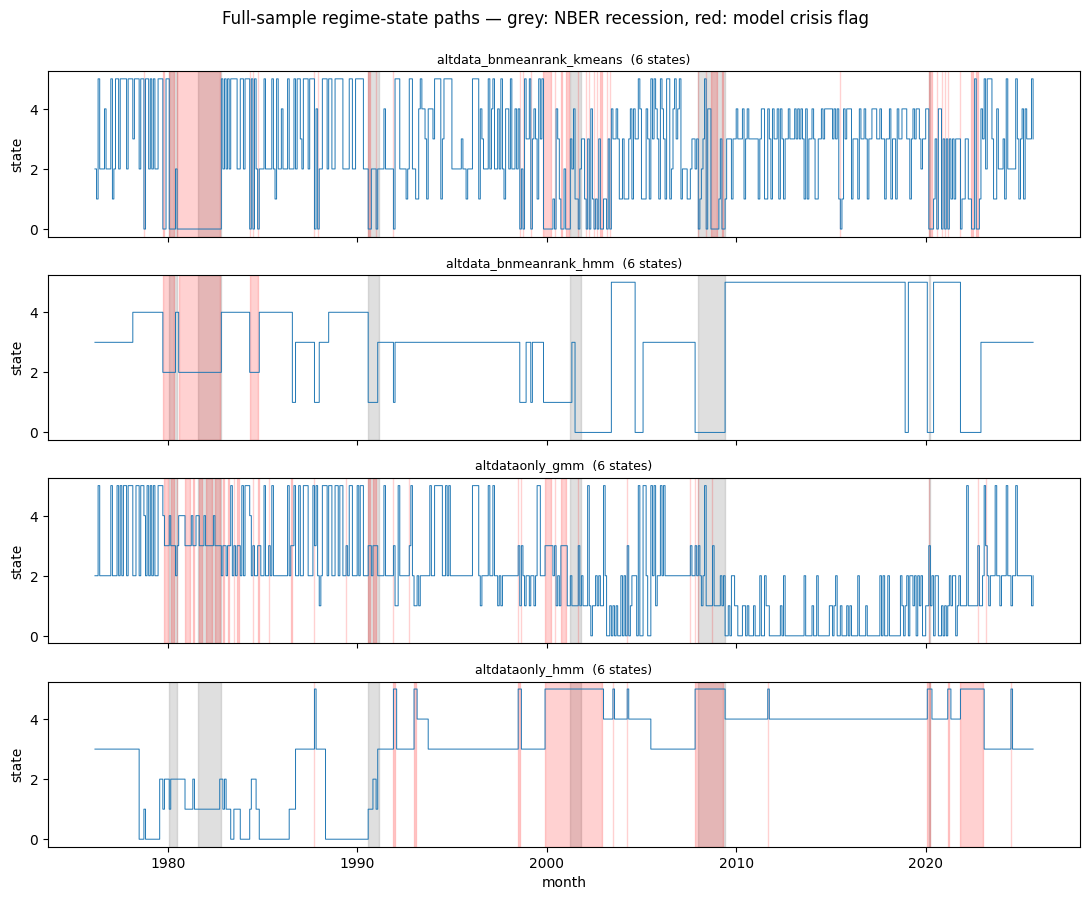

In [11]:
names = ['altdata_bnmeanrank_kmeans','altdata_bnmeanrank_hmm','altdataonly_gmm','altdataonly_hmm']
fig, axes = plt.subplots(len(names), 1, figsize=(11, 9), sharex=True)
for ax, nm in zip(axes, names):
    f = FULL[nm]; idx = f['scores'].index
    ax.plot(idx, f['states'], drawstyle='steps-post', lw=0.7, color='C0')
    ur = usrec.reindex(idx).fillna(0).values
    ax.fill_between(idx, 0, 1, where=ur > 0, transform=ax.get_xaxis_transform(),
                    color='grey', alpha=0.25, step='post')
    ax.fill_between(idx, 0, 1, where=np.array(f['crisis']) > 0, transform=ax.get_xaxis_transform(),
                    color='red', alpha=0.18, step='post')
    ax.set_ylabel('state'); ax.set_title(f"{nm}  ({SUMMARY[nm]['n_states']} states)", fontsize=9)
axes[-1].set_xlabel('month')
fig.suptitle('Full-sample regime-state paths — grey: NBER recession, red: model crisis flag', y=0.995)
fig.tight_layout(); fig.savefig(OUT/'fig_state_paths.png', dpi=120, bbox_inches='tight')
print('wrote', (OUT/'fig_state_paths.png').name); plt.show()

## 12 · Reading the outputs — caveats

* **All engines use 6 states** — k-means: state 0 = the Mahalanobis-outlier / crisis state
  + 5 cosine regimes; GMM/HMM: 6 mixture / hidden states. (The project's grid KM *detector*
  uses `r=6` / 7 states; here KM is set to `r=5` so all three engines are 6-state and
  directly comparable.)
* **k-means probabilities** are the paper's soft-membership (Eq 1–4), not true posteriors;
  GMM `predict_proba` and HMM filtered posteriors **are** native.
* **Full-sample vs walk-forward.** Full-sample is the clean descriptive path (consistent
  state ids, full 1976–2025). In walk-forward, only `crisis` / `p_crisis` are comparable
  across months — the non-crisis state ids are window-local (no Hungarian re-matching).
* **HMM is erratic** by project convention (degenerate / unstable across seeds — see the
  ARI column); report it, don't over-trust it. k-means ≥ GMM ≫ HMM for robustness.
* **N≈1 OOS recessions.** Conditional Sharpe / drawdown are computed over 2004+ where SPY
  exists; the recession signal there is dominated by 2008 (+ COVID). Treat the
  crisis-overlay numbers as illustrative, not statistically powered.